TensorFlow version: 2.22.0-rc0
NumPy version: 2.5.3

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training set: 60000 images of size 28x28
Test set: 10000 images of size 28x28
 Pixel value range: [0, 255]
 Number of classes: 10 (digits 0-9)

Training set class distribution:
   Digit 0: 5,923 images (9.9%)
   Digit 1: 6,742 images (11.2%)
   Digit 2: 5,958 images (9.9%)
   Digit 3: 6,131 images (10.2%)
   Digit 4: 5,842 images (9.7%)
   Digit 5: 5,421 images (9.0%)
   Digit 6: 5,918 images (9.9%)
   Digit 7: 6,265 images (10.4%)
   Digit 8: 5,851 images (9.8%)
   Digit 9: 5,949 images (9.9%)


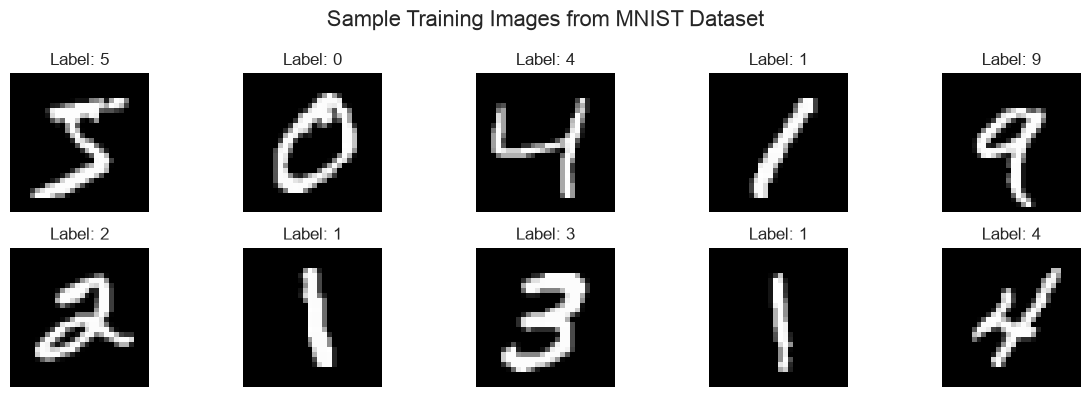


Cell 1 completed! Dataset loaded and explored.


In [1]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 1: LOAD & EXPLORE DATASET
# =============================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Load MNIST dataset
print("\n Loading MNIST dataset...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Basic dataset info
print(f" Training set: {train_images.shape[0]} images of size {train_images.shape[1]}x{train_images.shape[2]}")
print(f"Test set: {test_images.shape[0]} images of size {test_images.shape[1]}x{test_images.shape[2]}")
print(f"Pixel value range: [{train_images.min()}, {train_images.max()}]")
print(f"Number of classes: {len(np.unique(train_labels))} (digits 0-9)")

# Show class distribution
unique, counts = np.unique(train_labels, return_counts=True)
print(f"\n Training set class distribution:")
for digit, count in zip(unique, counts):
    print(f"   Digit {digit}: {count:,} images ({count/len(train_labels)*100:.1f}%)")

# Visualize first few training images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.suptitle('Sample Training Images from MNIST Dataset', fontsize=16)
plt.tight_layout()
plt.show()

print("\n1 Cell 1 completed! Dataset loaded and explored.")

Data preprocessing completed:
   • Original train shape: (60000, 28, 28) → Normalized: (60000, 28, 28, 1)
   • Original test shape: (10000, 28, 28) → Normalized: (10000, 28, 28, 1)
   • Train labels shape: (60000,) → Categorical: (60000, 10)
   • Test labels shape: (10000,) → Categorical: (10000, 10)
   • Pixel value range after normalization: [0.0, 1.0]

One-hot encoding verification:
   • First 5 train labels: [5 0 4 1 9]
   • Corresponding one-hot vectors:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


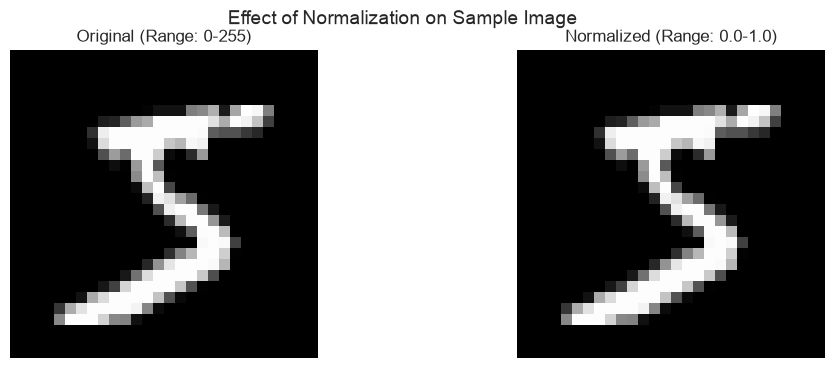


Cell 2 completed! Data preprocessed and ready for model building.


In [2]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 2: DATA PREPROCESSING
# =============================================

# Normalize pixel values to be between 0 and 1
train_images_norm = train_images.astype("float32") / 255.0
test_images_norm = test_images.astype("float32") / 255.0

# Reshape for CNN (add channel dimension) - Required for Conv2D layers
train_images_norm = train_images_norm.reshape(-1, 28, 28, 1)
test_images_norm = test_images_norm.reshape(-1, 28, 28, 1)

# Convert labels to categorical one-hot encoding (for categorical_crossentropy loss)
train_labels_cat = tf.keras.utils.to_categorical(train_labels, 10)
test_labels_cat = tf.keras.utils.to_categorical(test_labels, 10)

print("🔧 Data preprocessing completed:")
print(f"   • Original train shape: {train_images.shape} → Normalized: {train_images_norm.shape}")
print(f"   • Original test shape: {test_images.shape} → Normalized: {test_images_norm.shape}")
print(f"   • Train labels shape: {train_labels.shape} → Categorical: {train_labels_cat.shape}")
print(f"   • Test labels shape: {test_labels.shape} → Categorical: {test_labels_cat.shape}")
print(f"   • Pixel value range after normalization: [{train_images_norm.min():.1f}, {train_images_norm.max():.1f}]")

# Verify one-hot encoding
print(f"\n One-hot encoding verification:")
print(f"   • First 5 train labels: {train_labels[:5]}")
print(f"   • Corresponding one-hot vectors:\n{train_labels_cat[:5]}")

# Optional: Visualize the effect of normalization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(train_images[0], cmap='gray')
plt.title(f'Original (Range: {train_images.min()}-{train_images.max()})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(train_images_norm[0].squeeze(), cmap='gray')
plt.title(f'Normalized (Range: {train_images_norm.min():.1f}-{train_images_norm.max():.1f})')
plt.axis('off')
plt.suptitle('Effect of Normalization on Sample Image', fontsize=14)
plt.show()

print("\n Cell 2 completed! Data preprocessed and ready for model building.")

In [4]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 3: BUILD NEURAL NETWORK ARCHITECTURE
# =============================================

# Build the CNN model
model = tf.keras.Sequential([
    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout for regularization
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# Display model architecture
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Model compiled successfully!")
print("Ready to train the neural network.")

/Users/sarthak/AIML-RECRUITMENT-2026-SARTHAK VERMA /venv/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


Model compiled successfully!
Ready to train the neural network.


 Starting model training...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8771 - loss: 0.3917 - val_accuracy: 0.9820 - val_loss: 0.0619
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9669 - loss: 0.1169 - val_accuracy: 0.9873 - val_loss: 0.0426
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9760 - loss: 0.0858 - val_accuracy: 0.9892 - val_loss: 0.0375
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9815 - loss: 0.0638 - val_accuracy: 0.9902 - val_loss: 0.0337
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9838 - loss: 0.0555 - val_accuracy: 0.9905 - val_loss: 0.0354
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9856 - loss: 0.0483 - val_accuracy: 0.9913 - val_loss: 0.0357
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9883 - loss: 0.0412 - val_accuracy: 0.9910 - val_loss: 0.0353
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.98

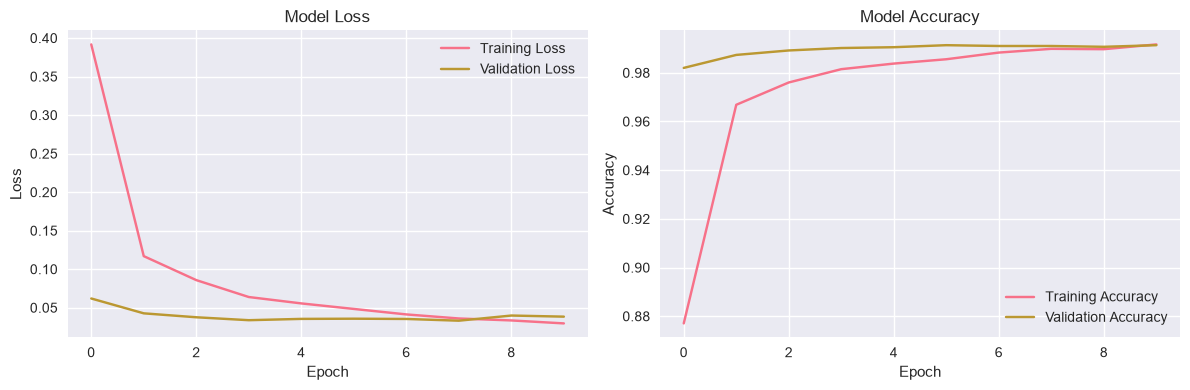


Model saved as 'mnist_model.h5'


In [5]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 4: MODEL TRAINING
# =============================================

# Train the model
print(" Starting model training...")
history = model.fit(
    train_images_norm, train_labels_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

print("\n Model training completed!")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save('mnist_model.h5')
print("\n Model saved as 'mnist_model.h5'")

Test accuracy: 0.9912
 Test loss: 0.0262
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


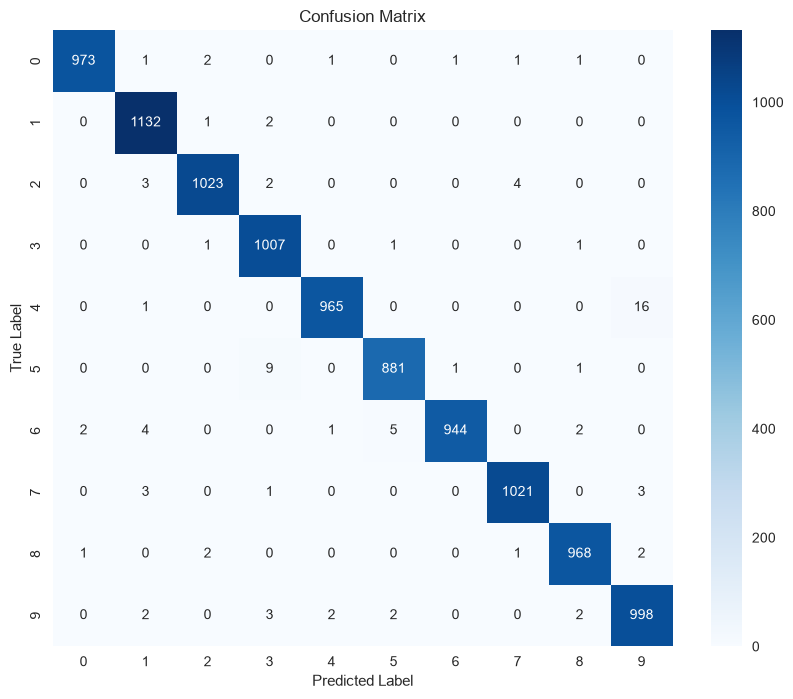


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



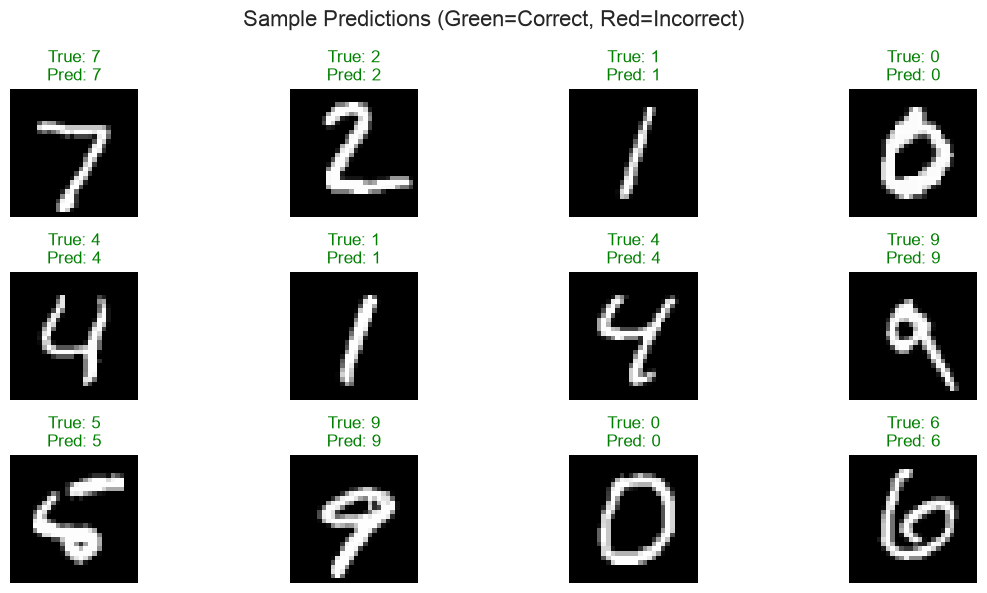


 Cell 5 completed! Model evaluated and visualized.


In [6]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 5: MODEL EVALUATION & VISUALIZATION
# =============================================

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_images_norm, test_labels_cat, verbose=0)
print(f" Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Make predictions
predictions = model.predict(test_images_norm)
predicted_labels = np.argmax(predictions, axis=1)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, predicted_labels))

# Visualize some predictions
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(test_images[i], cmap='gray')  # Use original for visualization (0-255 range)
    true_label = test_labels[i]
    pred_label = predicted_labels[i]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
    plt.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nCell 5 completed! Model evaluated and visualized.")

In [7]:
# =============================================
# MNIST NEURAL NETWORK TASK - CELL 6: FINAL ANALYSIS & INSIGHTS
# =============================================

print("🔍 MNIST NEURAL NETWORK: FINAL ANALYSIS")
print("=" * 45)

# Key findings summary
print("\n KEY FINDINGS:")
print(f"• Test Accuracy: Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"• Test Loss: {test_loss:.4f}")
print(f"• Model Parameters: {model.count_params():,}")

# Analyze misclassifications
misclassified_idx = np.where(predicted_labels != test_labels)[0]
if len(misclassified_idx) > 0:
    print(f"\nMisclassifications: {len(misclassified_idx)} out of {len(test_labels)} ({len(misclassified_idx)/len(test_labels)*100:.2f}%)")

    # Most confused digit pairs
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(test_labels, predicted_labels)
    # Remove correct predictions (diagonal) to find most confused pairs
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    max_confusion = np.unravel_index(np.argmax(cm_no_diag, axis=None), cm_no_diag.shape)
    print(f" Most confused pair: {max_confusion[0]} ↔ {max_confusion[1]} ({cm_no_diag[max_confusion]} occurrences)")
else:
    print("\n Perfect classification! No misclassifications found.")

# Model size analysis
print(f"\n Model size: {model.count_params()} parameters")
print(f"   • Approximately {model.count_params() * 4 / 1024:.1f} KB (assuming float32)")

# Training efficiency
epochs_trained = len(history.history['loss'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n Training efficiency:")
print(f"   • Epochs trained: {epochs_trained}")
print(f"   • Final training accuracy: {final_train_acc:.4f}")
print(f"   • Final validation accuracy: {final_val_acc:.4f}")
print(f"   • Train-val gap: {abs(final_train_acc - final_val_acc):.4f}")

print("\n TASK COMPLETION CHECKLIST:")
print("• [x] Data loading and exploration")
print("• [x] Data preprocessing (normalization, reshaping, one-hot encoding)")
print("• [x] Model architecture design (CNN with Conv2D, MaxPooling, Dense, Dropout)")
print("• [x] Model compilation (Adam optimizer, categorical crossentropy)")
print("• [x] Model training (10 epochs with validation split)")
print("• [x] Model evaluation (test accuracy, loss, confusion matrix)")
print("• [x] Results visualization (predictions, misclassifications)")
print("• [x] Model saving (mnist_model.h5)")

print("\nMNIST NEURAL NETWORK TASK COMPLETE!")
print("Both Air Quality Forecasting and MNIST Neural Network tasks are finished!")
print("Ready to commit and push final work to GitHub.")

 MNIST NEURAL NETWORK: FINAL ANALYSIS

 KEY FINDINGS:
• Test Accuracy: Test Accuracy: 0.9912 (99.12%)
• Test Loss: 0.0262
• Model Parameters: 93,322

 Misclassifications: 88 out of 10000 (0.88%)
 Most confused pair: 4 ↔ 9 (16 occurrences)

 Model size: 93322 parameters
   • Approximately 364.5 KB (assuming float32)

 Training efficiency:
   • Epochs trained: 10
   • Final training accuracy: 0.9916
   • Final validation accuracy: 0.9913
   • Train-val gap: 0.0003

 TASK COMPLETION CHECKLIST:
• [x] Data loading and exploration
• [x] Data preprocessing (normalization, reshaping, one-hot encoding)
• [x] Model architecture design (CNN with Conv2D, MaxPooling, Dense, Dropout)
• [x] Model compilation (Adam optimizer, categorical crossentropy)
• [x] Model training (10 epochs with validation split)
• [x] Model evaluation (test accuracy, loss, confusion matrix)
• [x] Results visualization (predictions, misclassifications)
• [x] Model saving (mnist_model.h5)

 MNIST NEURAL NETWORK TASK COMPLETE!
